In [ ]:
import sys

sys.path.append("..")

import torch
import torch.optim as optim
from tqdm import trange
import matplotlib.pyplot as plt
import numpy as np

from src.muon import SingleDeviceMuon, zeropower_via_newtonschulz5

torch.manual_seed(42)
input_dim = 10
output_dim = 5
num_samples = 1000
batch_size = 64
num_epochs = 500

## Simple linear regression with a matrix weight

100%|██████████| 500/500 [00:02<00:00, 174.61it/s]


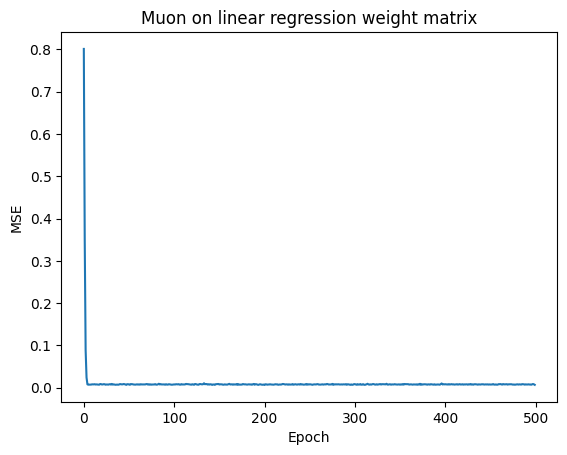

Final MSE: 0.006648


In [ ]:
W_true = torch.randn(input_dim, output_dim) / input_dim**0.5

X = torch.randn(num_samples, input_dim)
y = X @ W_true + 0.01 * torch.randn(num_samples, output_dim)

W = torch.nn.Parameter(torch.randn(input_dim, output_dim) / input_dim**0.5)

optimizer = SingleDeviceMuon([W], lr=0.1, momentum=0.95, weight_decay=0.0)

losses = []
for epoch in trange(num_epochs):
    indices = torch.randperm(num_samples)
    epoch_loss = 0.0
    for start in range(0, num_samples, batch_size):
        idx = indices[start : start + batch_size]
        Xb, yb = X[idx], y[idx]
        pred = Xb @ W
        loss = ((pred - yb) ** 2).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)
    losses.append(epoch_loss / num_samples)

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Muon on linear regression weight matrix")
plt.show()

with torch.no_grad():
    final_mse = ((X @ W - y) ** 2).mean().item()
print(f"Final MSE: {final_mse:.6f}")

## Newton‑Schulz orthogonalisation step

In [ ]:
G = torch.randn(5, 5)
print("Original G singular values:")
print(torch.linalg.svdvals(G))

X = zeropower_via_newtonschulz5(G, steps=5).to(torch.float32)
print("\nAfter NS (steps=5) singular values:")
print(torch.linalg.svdvals(X))

I = torch.eye(5)
print("\n||X X^T - I||:", torch.norm(X @ X.T - I).item())

Original G singular values:
tensor([3.4031, 2.2025, 1.2506, 1.0421, 0.2022])

After NS (steps=5) singular values:
tensor([1.0581, 0.9400, 0.7747, 0.7678, 0.7398])

||X X^T - I||: 0.7490776777267456


## Compare Muon with Adam and SGD

100%|██████████| 500/500 [00:01<00:00, 273.33it/s]


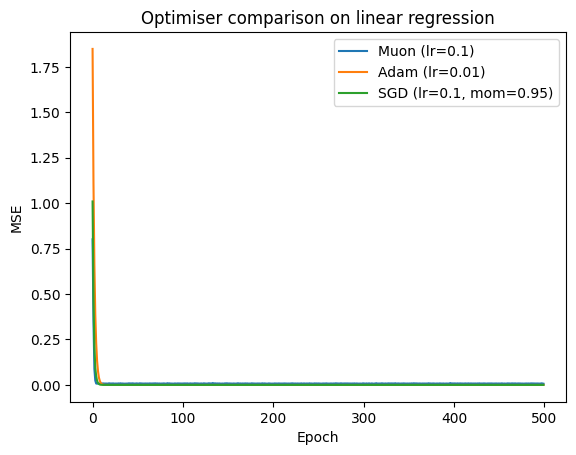

In [18]:
W_adam = torch.nn.Parameter(torch.randn(input_dim, output_dim) / input_dim**0.5)
optimizer_adam = optim.Adam([W_adam], lr=0.01)

losses_adam = []
for epoch in trange(num_epochs):
    indices = torch.randperm(num_samples)
    epoch_loss = 0.0
    for start in range(0, num_samples, batch_size):
        idx = indices[start : start + batch_size]
        Xb, yb = X[idx], y[idx]
        pred = Xb @ W_adam
        loss = ((pred - yb) ** 2).mean()
        optimizer_adam.zero_grad()
        loss.backward()
        optimizer_adam.step()
        epoch_loss += loss.item() * len(idx)
    losses_adam.append(epoch_loss / num_samples)

W_sgd = torch.nn.Parameter(torch.randn(input_dim, output_dim) / input_dim**0.5)
optimizer_sgd = optim.SGD([W_sgd], lr=0.1, momentum=0.95)

losses_sgd = []
for epoch in range(num_epochs):
    indices = torch.randperm(num_samples)
    epoch_loss = 0.0
    for start in range(0, num_samples, batch_size):
        idx = indices[start : start + batch_size]
        Xb, yb = X[idx], y[idx]
        pred = Xb @ W_sgd
        loss = ((pred - yb) ** 2).mean()
        optimizer_sgd.zero_grad()
        loss.backward()
        optimizer_sgd.step()
        epoch_loss += loss.item() * len(idx)
    losses_sgd.append(epoch_loss / num_samples)

plt.plot(losses, label="Muon (lr=0.1)")
plt.plot(losses_adam, label="Adam (lr=0.01)")
plt.plot(losses_sgd, label="SGD (lr=0.1, mom=0.95)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.title("Optimiser comparison on linear regression")
plt.show()

## Muon on a 2D quadratic

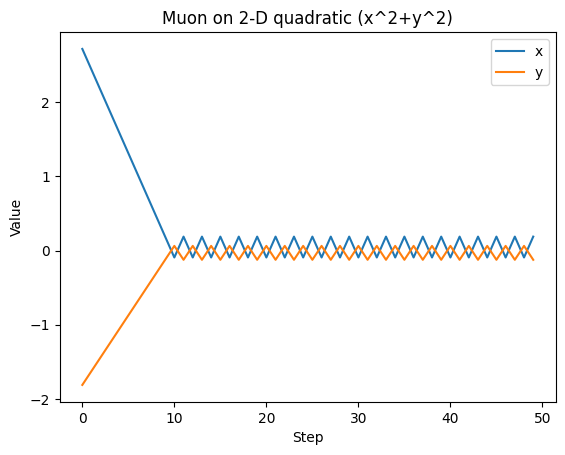

Final param: [[ 0.1875 -0.125 ]]


In [13]:
param = torch.nn.Parameter(torch.tensor([[3.0, -2.0]]))
optimizer = SingleDeviceMuon([param], lr=0.5, momentum=0.0)


def loss_fn(p):
    return (p[0, 0] ** 2 + p[0, 1] ** 2) / 2.0


values = []
for step in range(50):
    optimizer.zero_grad()
    loss = loss_fn(param)
    loss.backward()
    optimizer.step()
    values.append(param.clone().detach().numpy().flatten())

values = np.array(values)
plt.plot(values[:, 0], label="x")
plt.plot(values[:, 1], label="y")
plt.xlabel("Step")
plt.ylabel("Value")
plt.legend()
plt.title("Muon on 2‑D quadratic (x^2+y^2)")
plt.show()
print("Final param:", param.detach().numpy())